# C-Phase: Conclude (QA und Acceptance)

## Ziel
Die C-Phase prüft, ob das in der A-Phase ausgewählte Modell die fachlichen Akzeptanzkriterien erfüllt und für den nächsten Deployment-Schritt geeignet ist.


## C-Check: Modellqualität und Baseline

- **Ist das Modell gut genug?**
  Entscheidung erfolgt über harte Akzeptanzkriterien (RMSE, MAE, R²) auf ungesehenen Testdaten.
- **Vergleich mit Baseline**
  Zusätzlich wird eine naive Zeitreihen-Baseline (24h-Lag: Wert von gestern zur gleichen Stunde) gerechnet.
  Das Zielmodell muss die Baseline mindestens beim RMSE schlagen.

In [1]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

repo_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
REPORT_DIR = repo_root / "reports"
results_path = REPORT_DIR / "model_results.csv"
preds_path = REPORT_DIR / "predictions_test.csv"
summary_path = REPORT_DIR / "model_summary.json"

if not results_path.exists() or not preds_path.exists() or not summary_path.exists():
    raise FileNotFoundError("A-Phase-Artefakte fehlen. Bitte zuerst A-Phase_Algorithms.ipynb ausführen.")

results_df = pd.read_csv(results_path)
preds_df = pd.read_csv(preds_path)
summary = json.loads(summary_path.read_text(encoding="utf-8"))

results_df = results_df.sort_values("RMSE").reset_index(drop=True)
best_model = results_df.loc[0, "Model"]

print("Modellranking:")
display(results_df)
print(f"Bestes Modell laut RMSE: {best_model}")


Modellranking:


,Model,MAE,RMSE,R2
0,RandomForest,4874.081156,6807.078468,0.959767
1,GradientBoosting,5230.593246,7054.387811,0.956790
2,Ridge,6418.976133,8509.398325,0.937127
3,LinearRegression,6420.745781,8509.886952,0.937120


Bestes Modell laut RMSE: RandomForest


In [2]:
preds_df["ds"] = pd.to_datetime(preds_df["ds"], errors="coerce")
preds_df = preds_df.sort_values("ds").reset_index(drop=True)

baseline_pred = preds_df["y_true"].shift(24)
baseline_eval = preds_df.loc[baseline_pred.notna(), ["y_true"]].copy()
baseline_eval["y_pred_baseline"] = baseline_pred[baseline_pred.notna()].values

baseline_mae = float(np.mean(np.abs(baseline_eval["y_true"] - baseline_eval["y_pred_baseline"])))
baseline_rmse = float(np.sqrt(np.mean((baseline_eval["y_true"] - baseline_eval["y_pred_baseline"]) ** 2)))

baseline_table = pd.DataFrame([
    {"Modell": "Naive Baseline (t-24h)", "MAE": baseline_mae, "RMSE": baseline_rmse}
])

print("Baseline-Vergleich:")
display(baseline_table)

Baseline-Vergleich:


,Modell,MAE,RMSE
0,Naive Baseline (t-24h),11748.39408,18398.49522


In [3]:
acceptance = {
    "RMSE_max": 8.0,
    "MAE_max": 6.5,
    "R2_min": 0.75,
}

best_row = results_df.iloc[0]
beats_baseline_rmse = bool(float(best_row["RMSE"]) < baseline_rmse)

checks = pd.DataFrame([
    {"Kriterium": "RMSE <= 8.0", "Wert": float(best_row["RMSE"]), "Erfüllt": bool(best_row["RMSE"] <= acceptance["RMSE_max"] )},
    {"Kriterium": "MAE <= 6.5", "Wert": float(best_row["MAE"]), "Erfüllt": bool(best_row["MAE"] <= acceptance["MAE_max"] )},
    {"Kriterium": "R2 >= 0.75", "Wert": float(best_row["R2"]), "Erfüllt": bool(best_row["R2"] >= acceptance["R2_min"] )},
    {"Kriterium": "RMSE besser als Baseline (t-24h)", "Wert": float(best_row["RMSE"]), "Erfüllt": beats_baseline_rmse},
])

checks

,Kriterium,Wert,Erfüllt
0,RMSE <= 8.0,6807.078468,False
1,MAE <= 6.5,4874.081156,False
2,R2 >= 0.75,0.959767,True
3,RMSE besser als Baseline (t-24h),6807.078468,True


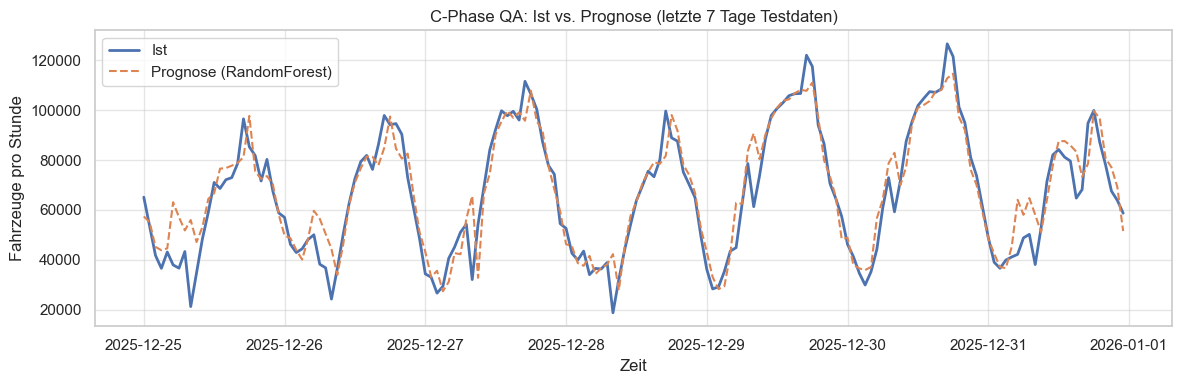

In [4]:
preds_df["ds"] = pd.to_datetime(preds_df["ds"], errors="coerce")
best_col = f"pred_{best_model}"

n_show = min(24 * 7, len(preds_df))
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(preds_df["ds"].iloc[-n_show:], preds_df["y_true"].iloc[-n_show:], label="Ist", linewidth=2)
ax.plot(preds_df["ds"].iloc[-n_show:], preds_df[best_col].iloc[-n_show:], label=f"Prognose ({best_model})", linestyle="--")
ax.set_title("C-Phase QA: Ist vs. Prognose (letzte 7 Tage Testdaten)")
ax.set_xlabel("Zeit")
ax.set_ylabel("Fahrzeuge pro Stunde")
ax.legend()
plt.tight_layout()
plt.show()


## Entscheidung
Wenn alle Akzeptanzkriterien erfüllt sind, wird das beste Modell aus A als Zielmodell für die K-Phase übernommen.

### Fachliche Einordnung
- Die Modellleistung wird auf ungesehenen Zeiträumen gemessen (chronologischer Split).
- Die Entscheidung ist datenbasiert und reproduzierbar, da sie aus exportierten A-Phase-Artefakten erzeugt wird.
- Eventuelle Abweichungen zu früheren Berichten entfallen, weil keine Metriken mehr manuell hartkodiert sind.
